In [1]:
import pandas as pd

In [2]:
games = pd.DataFrame({
    "game": ["Stardew Valley", "Animal Crossing", "Spiritfarer"],
    "genre": ["Farming Sim", "Life Sim", "Adventure"]
})

games

,game,genre
0,Stardew Valley,Farming Sim
1,Animal Crossing,Life Sim
2,Spiritfarer,Adventure


# What Makes a Cozy Game? 🎮

## Exploring patterns in cozy games using Python

This project explores characteristics and trends among cozy video games using data analysis and machine learning.

### Questions
- What characteristics are common among cozy games?
- Which tags and genres frequently appear together?
- Can games be grouped into meaningful clusters based on their characteristics?
- What patterns distinguish highly rated or popular cozy games?

In [3]:
df = pd.read_csv("steam_cleaned_2026.csv")

In [4]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots
0,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...
1,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...
2,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...
3,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...
4,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,0,13.99,0,0,A JOURNEY THROUGH HELL! Explore the most terri...,...,0,0,0,0,Ignibit,"Ignibit,Madmind Studio","Single-player,Tracked Controller Support,VR On...","Action,Adventure",NaN,https://shared.akamai.steamstatic.com/store_it...


In [5]:
df.columns.tolist()

['AppID',
 'Name',
 'Release date',
 'Estimated owners',
 'Peak CCU',
 'Required age',
 'Price',
 'Discount',
 'DLC count',
 'About the game',
 'Supported languages',
 'Full audio languages',
 'Reviews',
 'Header image',
 'Website',
 'Support url',
 'Support email',
 'Windows',
 'Mac',
 'Linux',
 'Metacritic score',
 'Metacritic url',
 'User score',
 'Positive',
 'Negative',
 'Achievements',
 'Recommendations',
 'Notes',
 'Average playtime forever',
 'Average playtime two weeks',
 'Median playtime forever',
 'Median playtime two weeks',
 'Developers',
 'Publishers',
 'Categories',
 'Genres',
 'Tags',
 'Screenshots']

In [6]:
df.shape

(114172, 38)

In [7]:
df[["Name", "Genres", "Tags"]].head(10)

,Name,Genres,Tags
0,Supipara - Chapter 1 Spring Has Come!,Adventure,"Adventure,Visual Novel,Anime,Cute"
1,Mystery Solitaire The Black Raven,Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
2,버튜버 파라노이아 - Vtuber Paranoia,"Casual,Indie,Simulation",NaN
3,Maze Quest VR,"Action,Early Access",NaN
4,Agony VR,"Action,Adventure",NaN
5,Armored Brigade II,"Simulation,Strategy","Simulation,Strategy,RTS,Wargame,Grand Strategy..."
6,Galacatraz: Eject Equip Escape,"Action,Indie",NaN
7,Hepta Beats,"Casual,Indie","Precision Platformer,Rhythm,Music,Difficult,Ab..."
8,MUMBA IV: Egypt Jewels,"Action,Casual,Indie,Strategy","Casual,Action,Strategy,Puzzle,Match 3,Singlepl..."
9,OMNIMUS,"Adventure,Indie","Adventure,Indie,Visual Novel,Interactive Ficti..."


In [8]:
df["Tags"].str.split(",").explode().value_counts().head(30)

Tags
Singleplayer        50245
Indie               48487
Action              36698
Casual              36520
Adventure           35113
2D                  26773
3D                  17980
Simulation          17850
Strategy            17811
Puzzle              16332
Atmospheric         16222
RPG                 15711
Colorful            14254
Pixel Graphics      13860
Story Rich          13294
Exploration         13208
Cute                12673
First-Person        12253
Arcade              11489
Fantasy             11483
Early Access        10219
Multiplayer         10082
Funny                9849
Horror               9657
Action-Adventure     9573
Retro                9254
Shooter              9156
Relaxing             9113
Family Friendly      8896
Platformer           8789
Name: count, dtype: int64

In [9]:
relaxing_games = df[
    df["Tags"].fillna("").str.contains("Relaxing", case=False)
]

relaxing_games.shape

(9113, 38)

In [10]:
relaxing_games[["Name", "Genres", "Tags"]].head(10)

,Name,Genres,Tags
12,DogDogDog,"Adventure,Casual,Indie","Dog,Cute,Walking Simulator,Psychological Horro..."
60,Eastshade,"Adventure,Indie","Exploration,Relaxing,Open World,Beautiful,Atmo..."
63,ARCHiTECTUS,"Casual,Indie,Simulation,Early Access","Indie,Early Access,Casual,Simulation,Design & ..."
67,Block Pieces - 3D Jigsaw Puzzle,"Casual,Indie","Casual,Indie,Puzzle,Relaxing,3D,Clicker,Strate..."
68,Hole in Won,"Casual,Indie","Casual,Mini Golf,Puzzle,Arcade,Level Editor,Co..."
100,Dancing Hime: Rhythm Matching,"Casual,Early Access","Casual,Match 3,Rhythm,VR,Early Access,Relaxing..."
111,ReThink | Evolved 5,Indie,"Adventure,Puzzle,3D,Abstract,First-Person,Indi..."
121,Car Crash X,"Racing,Simulation","Racing,Automobile Sim,Combat Racing,3D,3D Visi..."
128,I commissioned some letters,"Casual,Indie","Hidden Object,Relaxing,Family Friendly,Hand-dr..."
155,Kitchinko,"Casual,Indie","Arcade,2D,Relaxing,Casual,Pixel Graphics,Level..."


In [11]:
relaxing_tag_counts = (
    relaxing_games["Tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

relaxing_tag_counts.head(30)

Tags
Relaxing           9113
Casual             7365
Singleplayer       7138
Indie              5136
2D                 4241
Puzzle             3970
Colorful           3846
Cute               3630
Family Friendly    3452
Atmospheric        3041
Simulation         3001
Adventure          2894
3D                 2571
Strategy           2316
Exploration        2067
Minimalist         2026
Funny              1795
Stylized           1681
Logic              1672
Action             1538
Pixel Graphics     1406
Point & Click      1380
Nature             1337
Arcade             1333
Fantasy            1332
First-Person       1279
Cartoony           1244
Physics            1203
Story Rich         1202
Sandbox            1084
Name: count, dtype: int64

In [12]:
cozy_candidates = df[
    df["Tags"].fillna("").str.contains("Relaxing", case=False) &
    df["Tags"].fillna("").str.contains("Cute", case=False)
]

cozy_candidates.shape

(3630, 38)

In [13]:
cozy_candidates[
    ["Name", "Genres", "Tags", "Positive", "Negative"]
].head(20)

,Name,Genres,Tags,Positive,Negative
12,DogDogDog,"Adventure,Casual,Indie","Dog,Cute,Walking Simulator,Psychological Horro...",34,10
67,Block Pieces - 3D Jigsaw Puzzle,"Casual,Indie","Casual,Indie,Puzzle,Relaxing,3D,Clicker,Strate...",6,0
68,Hole in Won,"Casual,Indie","Casual,Mini Golf,Puzzle,Arcade,Level Editor,Co...",34,5
173,Lips Breaker,"Casual,Indie","Level Editor,Casual,Pinball,Physics,Quick-Time...",3,0
190,Doll Catching Simulator,"Casual,Indie,Simulation,Free To Play","Simulation,Casual,Relaxing,Indie,Life Sim,Crea...",20,5
264,Urchins and Ink,"Action,Casual,Indie","Casual,Education,Action,Twin Stick Shooter,Puz...",5,0
278,Aisling and the Tavern of Elves,"Casual,Indie","LGBTQ+,Visual Novel,Female Protagonist,Sexual ...",19,9
297,Kinder Finders,Casual,"Casual,Point & Click,Hidden Object,Cartoon,Car...",14,0
308,Pixel Boy - Lost in the Castle,"Adventure,Casual,Indie","Puzzle,Sokoban,2D,Puzzle-Platformer,Family Fri...",5,1
310,True Visions,"Casual,Indie,Simulation,Early Access","Early Access,Design & Illustration,Casual,Simu...",5,4


In [14]:
cozy_tags = [
    "Relaxing",
    "Cute",
    "Family Friendly",
    "Colorful",
    "Atmospheric",
    "Exploration",
    "Nature",
    "Cartoony",
    "Life Sim",
    "Farming Sim"
]

In [15]:
cozy_tags

['Relaxing',
 'Cute',
 'Family Friendly',
 'Colorful',
 'Atmospheric',
 'Exploration',
 'Nature',
 'Cartoony',
 'Life Sim',
 'Farming Sim']

In [16]:
for tag in cozy_tags:
    df[tag] = df["Tags"].fillna("").str.contains(tag, case=False).astype(int)


In [17]:
df[["Name"] + cozy_tags].head(10)

,Name,Relaxing,Cute,Family Friendly,Colorful,Atmospheric,Exploration,Nature,Cartoony,Life Sim,Farming Sim
0,Supipara - Chapter 1 Spring Has Come!,0,1,0,0,0,0,0,0,0,0
1,Mystery Solitaire The Black Raven,0,0,1,1,1,0,0,0,0,0
2,버튜버 파라노이아 - Vtuber Paranoia,0,0,0,0,0,0,0,0,0,0
3,Maze Quest VR,0,0,0,0,0,0,0,0,0,0
4,Agony VR,0,0,0,0,0,0,0,0,0,0
5,Armored Brigade II,0,0,0,0,0,0,0,0,0,0
6,Galacatraz: Eject Equip Escape,0,0,0,0,0,0,0,0,0,0
7,Hepta Beats,0,0,0,1,0,0,0,0,0,0
8,MUMBA IV: Egypt Jewels,0,0,0,0,0,0,0,0,0,0
9,OMNIMUS,0,0,0,0,0,0,0,0,0,0


In [18]:
df["Cozy Score"] = df[cozy_tags].sum(axis=1)

In [19]:
df[
    ["Name", "Cozy Score", "Genres", "Tags"]
].sort_values("Cozy Score", ascending=False).head(20)

,Name,Cozy Score,Genres,Tags
39697,Summer in Mara Prologue,9,"Adventure,Casual","Hand-drawn,Anime,Cartoon,Female Protagonist,Li..."
62675,The Shepherd: Black Sheep,9,"Adventure,Casual,Indie,RPG","RPG,Casual,Life Sim,Visual Novel,Creature Coll..."
6959,Aka,8,"Adventure,Casual,Simulation","Life Sim,Simulation,Farming Sim,Cute,Relaxing,..."
48544,Bibi & Tina - New adventures with horses,8,"Simulation,Sports","Horses,Adventure,Colorful,Female Protagonist,R..."
66284,MY FOX - Desktop Wild Pet,8,"Adventure,Casual,Indie,Simulation,Early Access","Early Access,Adventure,Casual,Simulation,Life ..."
109524,Isle of Jura,8,"Casual,Indie","Exploration,Collectathon,Fishing,Nature,Walkin..."
51791,Holiday Farm,8,"Adventure,Casual,Indie,RPG","Adventure,Casual,Farming Sim,Life Sim,Sandbox,..."
71657,Critter Crops,8,"Adventure,Casual,Indie,RPG,Simulation","Singleplayer,Cozy,Casual,Farming Sim,RPG,Color..."
71706,Ultra Fishing,8,"Casual,Indie,Racing,Simulation","Casual,Simulation,Life Sim,Farming Sim,FPS,Imm..."
54588,Sunrise's Order,8,"Adventure,Casual,Indie,Simulation","Farming Sim,Agriculture,Building,Life Sim,2D,E..."


In [20]:
cozy_tagged_games = df[
    df["Tags"].fillna("").str.split(",").apply(lambda tags: "Cozy" in tags)
]

cozy_tagged_games.shape

(737, 49)

In [21]:
cozy_tagged_games[
    ["Name", "Genres", "Tags", "Positive", "Negative"]
].head(20)

,Name,Genres,Tags,Positive,Negative
67,Block Pieces - 3D Jigsaw Puzzle,"Casual,Indie","Casual,Indie,Puzzle,Relaxing,3D,Clicker,Strate...",6,0
90,Cat Quest II,"Action,Adventure,Indie,RPG","Adventure,Exploration,Action RPG,Hack and Slas...",6092,273
297,Kinder Finders,Casual,"Casual,Point & Click,Hidden Object,Cartoon,Car...",14,0
353,Tiny Kingdom,"Casual,Indie,Simulation,Strategy","City Builder,Roguelike Deckbuilder,Difficult,D...",85,23
380,me Igigu,"Action,Casual,Indie,Simulation","God Game,Sandbox,Cozy,Simulation,Action,Casual...",2,0
797,Belote 3 in 1,"Casual,Strategy","Casual,Card Game,Singleplayer,Strategy,Relaxin...",2,0
808,Summer in Mara,"Adventure,Casual,Indie,RPG,Simulation","Life Sim,Relaxing,Farming Sim,Cozy,Exploration...",1460,472
816,LEGO® Bricktales,"Adventure,Casual,Simulation","Puzzle,LEGO,Cozy,Colorful,Design & Illustratio...",1178,188
825,Topac Battle,Simulation,"Creature Collector,Idler,Clicker,Relaxing,Casu...",14,8
1017,Nekokami - The Human Restoration Project,"Adventure,Casual,Indie,RPG,Early Access","Early Access,Cute,Building,Story Rich,Colorful...",48,0


In [22]:
cozy_tagged_games.shape

(737, 49)

In [23]:
cozy_tag_counts = (
    cozy_tagged_games["Tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

cozy_tag_counts.head(30)

Tags
Cozy                  737
Singleplayer          634
Casual                615
Relaxing              589
Cute                  556
Colorful              422
Indie                 403
Family Friendly       388
Puzzle                350
Wholesome             334
2D                    330
Simulation            264
Exploration           245
Atmospheric           236
Adventure             234
Point & Click         214
Hand-drawn            202
Minimalist            196
3D                    193
Cartoony              193
Stylized              178
Funny                 171
Hidden Object         166
Cats                  160
Collectathon          139
Story Rich            138
Building              132
Nature                132
Creature Collector    128
Sandbox               127
Name: count, dtype: int64

In [24]:
all_tag_counts = (
    df["Tags"]
    .str.split(",")
    .explode()
    .value_counts()
)

tag_comparison = pd.DataFrame({
    "Cozy %": cozy_tag_counts / len(cozy_tagged_games) * 100,
    "All Games %": all_tag_counts / len(df) * 100
})

tag_comparison["Lift"] = (
    tag_comparison["Cozy %"] / tag_comparison["All Games %"]
)

tag_comparison.sort_values("Lift", ascending=False).head(20)

,Cozy %,All Games %,Lift
Tags,,,
Cozy,100.000000,0.645517,154.914518
Wholesome,45.318860,0.487860,92.893086
Shop Keeper,1.899593,0.040290,47.147897
Ambient,2.442334,0.097222,25.121273
Farming,3.934871,0.179554,21.914737
Creature Collector,17.367707,0.853975,20.337496
Job Simulator,2.170963,0.108608,19.988970
Time Attack,5.970149,0.306555,19.474968
Cats,21.709634,1.117612,19.425018


In [25]:
meaningful_cozy_tags = tag_comparison[
    (tag_comparison["Cozy %"] >= 10) &
    (tag_comparison.index != "Cozy")
].sort_values("Lift", ascending=False)

meaningful_cozy_tags.head(20)

,Cozy %,All Games %,Lift
Tags,,,
Wholesome,45.318860,0.487860,92.893086
Creature Collector,17.367707,0.853975,20.337496
Cats,21.709634,1.117612,19.425018
Farming Sim,12.075984,0.740987,16.297154
Collectathon,18.860244,1.534527,12.290592
Relaxing,79.918589,7.981817,10.012581
Life Sim,14.654003,1.806047,8.113854
Nature,17.910448,2.533020,7.070787
Hand-drawn,27.408412,3.926532,6.980311


Matplotlib is building the font cache; this may take a moment.


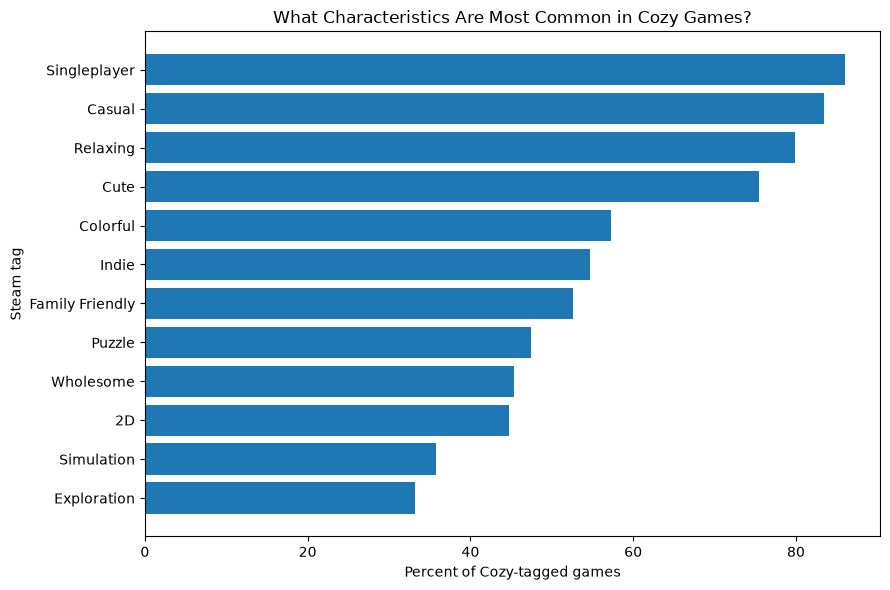

In [26]:
import matplotlib.pyplot as plt

top_cozy = (
    meaningful_cozy_tags
    .sort_values("Cozy %", ascending=False)
    .head(12)
    .sort_values("Cozy %")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_cozy.index,
    top_cozy["Cozy %"]
)

plt.xlabel("Percent of Cozy-tagged games")
plt.ylabel("Steam tag")
plt.title("What Characteristics Are Most Common in Cozy Games?")

plt.tight_layout()
plt.show()

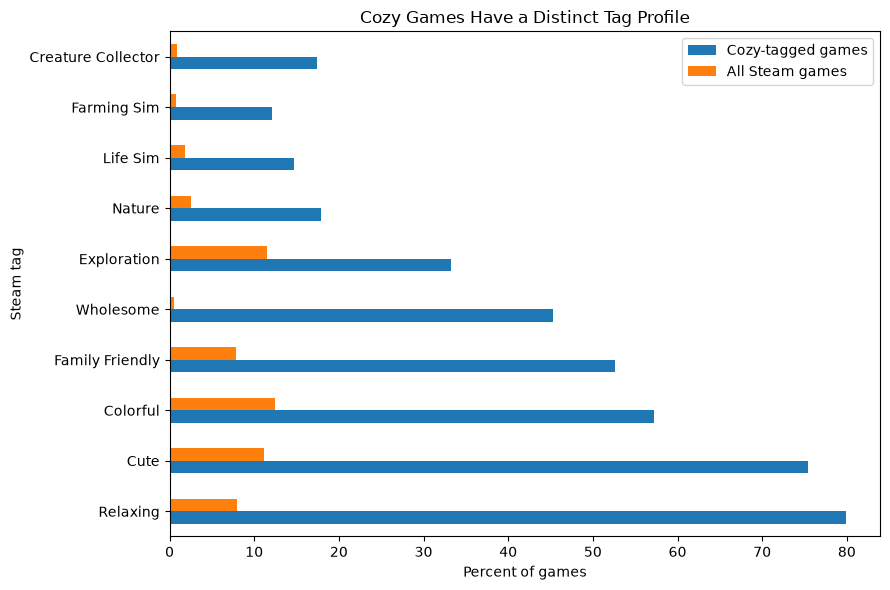

In [27]:
comparison_tags = [
    "Relaxing",
    "Cute",
    "Colorful",
    "Family Friendly",
    "Wholesome",
    "Exploration",
    "Nature",
    "Life Sim",
    "Farming Sim",
    "Creature Collector"
]

comparison_plot = tag_comparison.loc[comparison_tags, ["Cozy %", "All Games %"]]

comparison_plot.plot(
    kind="barh",
    figsize=(9, 6)
)

plt.xlabel("Percent of games")
plt.ylabel("Steam tag")
plt.title("Cozy Games Have a Distinct Tag Profile")
plt.legend(["Cozy-tagged games", "All Steam games"])

plt.tight_layout()
plt.show()

### Key Findings

Cozy-tagged games show a distinct combination of emotional, visual, and gameplay characteristics compared with the broader Steam catalog.

- **Relaxing** appears in approximately 80% of Cozy-tagged games, compared with only 8% of all games.
- **Cute** appears in approximately 75% of Cozy-tagged games, compared with 11% overall.
- **Wholesome** is particularly distinctive: it appears in about 45% of Cozy games but less than 1% of the full dataset.
- Gameplay tags including **Creature Collector, Farming Sim, and Life Sim** are also substantially more prevalent among Cozy-tagged games.

These results suggest that "cozy" is not defined by a single genre. Instead, cozy games appear to combine emotional qualities such as relaxation and wholesomeness, visual qualities such as cuteness and colorfulness, and gameplay patterns centered around simulation, collecting, exploration, and low-pressure activities.

## Clustering Cozy Games

To explore whether cozy games naturally form different subgroups, I use unsupervised machine learning to cluster games based on their Steam tags.

Rather than defining categories in advance, clustering allows games with similar characteristics to group together based on patterns in the data.

In [29]:
cluster_tags = [
    "Relaxing",
    "Cute",
    "Wholesome",
    "Colorful",
    "Family Friendly",
    "Exploration",
    "Nature",
    "Life Sim",
    "Farming Sim",
    "Creature Collector",
    "Collectathon",
    "Hand-drawn",
    "Point & Click",
    "Hidden Object",
    "Minimalist",
    "Building",
    "Cartoony",
    "Crafting",
    "Sandbox"
]

In [30]:
X = pd.DataFrame(index=cozy_tagged_games.index)

for tag in cluster_tags:
    X[tag] = (
        cozy_tagged_games["Tags"]
        .fillna("")
        .str.split(",")
        .apply(lambda tags: int(tag in tags))
    )

X.head()

,Relaxing,Cute,Wholesome,Colorful,Family Friendly,Exploration,Nature,Life Sim,Farming Sim,Creature Collector,Collectathon,Hand-drawn,Point & Click,Hidden Object,Minimalist,Building,Cartoony,Crafting,Sandbox
67,1,1,0,1,1,0,0,0,0,0,0,0,1,0,1,1,1,0,0
90,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
297,1,1,0,1,1,0,0,0,0,0,0,1,1,1,0,0,1,0,0
353,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1
380,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [31]:
X.shape

(737, 19)

In [32]:
import sklearn

sklearn.__version__

'1.9.0'

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = {}

for k in range(2, 9):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    scores[k] = silhouette_score(X, labels)

scores

{2: 0.1972215930028063,
 3: 0.13725430010688597,
 4: 0.13685333450718132,
 5: 0.14027932123217438,
 6: 0.13909979106372222,
 7: 0.14693163280004884,
 8: 0.14552829142306836}

In [34]:
for k in [2, 5, 7]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X)

    print(f"\n--- {k} CLUSTERS ---")
    print(pd.Series(labels).value_counts().sort_index())


--- 2 CLUSTERS ---
0    591
1    146
Name: count, dtype: int64

--- 5 CLUSTERS ---
0    258
1     64
2    165
3    149
4    101
Name: count, dtype: int64

--- 7 CLUSTERS ---
0     75
1    147
2    128
3     64
4     90
5     80
6    153
Name: count, dtype: int64


In [35]:
final_model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

cozy_tagged_games["Cluster"] = final_model.fit_predict(X)

cozy_tagged_games["Cluster"].value_counts().sort_index()

Cluster
0    258
1     64
2    165
3    149
4    101
Name: count, dtype: int64

In [36]:
cluster_profiles = pd.DataFrame(
    final_model.cluster_centers_,
    columns=X.columns
)

for cluster in cluster_profiles.index:
    print(f"\n--- CLUSTER {cluster} ---")

    print(
        cluster_profiles.loc[cluster]
        .sort_values(ascending=False)
        .head(8)
    )


--- CLUSTER 0 ---
Cute               0.910853
Colorful           0.883721
Relaxing           0.856589
Family Friendly    0.802326
Wholesome          0.476744
Exploration        0.298450
Nature             0.275194
Minimalist         0.217054
Name: 0, dtype: float64

--- CLUSTER 1 ---
Creature Collector    1.000000
Hidden Object         1.000000
Cute                  1.000000
Relaxing              1.000000
Wholesome             0.984375
Collectathon          0.968750
Point & Click         0.968750
Minimalist            0.953125
Name: 1, dtype: float64

--- CLUSTER 2 ---
Relaxing           0.484848
Cute               0.321212
Exploration        0.309091
Wholesome          0.248485
Colorful           0.224242
Family Friendly    0.212121
Point & Click      0.181818
Hand-drawn         0.175758
Name: 2, dtype: float64

--- CLUSTER 3 ---
Relaxing       0.845638
Cute           0.738255
Building       0.724832
Sandbox        0.637584
Colorful       0.570470
Crafting       0.442953
Life Sim    

In [37]:
for cluster in range(5):
    print(f"\n--- CLUSTER {cluster} ---")
    
    display(
        cozy_tagged_games[
            cozy_tagged_games["Cluster"] == cluster
        ][["Name", "Genres", "Tags"]].head(10)
    )


--- CLUSTER 0 ---


,Name,Genres,Tags
67,Block Pieces - 3D Jigsaw Puzzle,"Casual,Indie","Casual,Indie,Puzzle,Relaxing,3D,Clicker,Strate..."
797,Belote 3 in 1,"Casual,Strategy","Casual,Card Game,Singleplayer,Strategy,Relaxin..."
825,Topac Battle,Simulation,"Creature Collector,Idler,Clicker,Relaxing,Casu..."
1735,Hogvalord: The Ranch,"Casual,Indie,Simulation","Simulation,Creature Collector,Casual,Indie,Far..."
1927,Chillquarium,"Casual,Simulation","Creature Collector,Idler,Simulation,Relaxing,F..."
2168,Spurdo :D,"Action,Adventure,Indie","Memes,Comedy,Dark Humor,Cozy,Exploration,Cute,..."
2376,Heaven's Paws,"Adventure,Casual,Indie","Cute,Adventure,Atmospheric,Dog,Puzzle,Cozy,Emo..."
3015,CAT & ONION,"Adventure,Indie","Adventure,Wholesome,Short,Cats,Funny,Surreal,E..."
3232,Monch!,"Adventure,Casual,Indie","Casual,Cozy,Relaxing,Cute,Wholesome,Exploratio..."
4406,Fishing Tale,"Casual,Indie,Simulation","Casual,Clicker,Collectathon,Fishing,Cozy,Creat..."



--- CLUSTER 1 ---


,Name,Genres,Tags
2516,Cats Hidden in Germany,"Casual,Indie","Cats,Hidden Object,Wholesome,Puzzle,Cozy,Casua..."
7612,101 Cats Hidden in Berlin,"Casual,Indie","Cats,Hidden Object,Wholesome,Puzzle,Cozy,Casua..."
8139,Cats and Seek: Osaka,"Casual,Indie","Cats,Hidden Object,Free to Play,Wholesome,Puzz..."
8302,Cats Hidden in Italy,"Casual,Indie","Cats,Hidden Object,Wholesome,Puzzle,Cozy,Cute,..."
9998,100 Dogs,"Casual,Indie","Dog,Hidden Object,Cozy,Wholesome,Relaxing,Casu..."
10800,101 Cats Hidden in Miami,"Casual,Indie","Cats,Hidden Object,Wholesome,Puzzle,Cozy,Casua..."
11420,101 Cats Hidden in Ireland,"Casual,Indie","Cats,Hidden Object,Wholesome,Puzzle,Cozy,Casua..."
12405,100 Forest Cats,"Action,Adventure,Casual,Indie,Simulation,Strategy","Point & Click,Free to Play,Puzzle,Detective,Fa..."
19188,101 Cats Hidden in India,"Casual,Indie","Cats,Hidden Object,Wholesome,Puzzle,Cozy,Casua..."
19716,Mushroom Picnic Party,"Adventure,Casual","Hidden Object,Point & Click,Cozy,Wholesome,Han..."



--- CLUSTER 2 ---


,Name,Genres,Tags
90,Cat Quest II,"Action,Adventure,Indie,RPG","Adventure,Exploration,Action RPG,Hack and Slas..."
353,Tiny Kingdom,"Casual,Indie,Simulation,Strategy","City Builder,Roguelike Deckbuilder,Difficult,D..."
380,me Igigu,"Action,Casual,Indie,Simulation","God Game,Sandbox,Cozy,Simulation,Action,Casual..."
1504,Box #341,"Casual,Indie","Indie,Puzzle,Cozy,Casual,Puzzle-Platformer,2D,..."
2033,Harbor Captain,"Casual,Simulation","Cozy,Naval,Sailing,Relaxing,Simulation,Strateg..."
3297,Cat N Can,"Adventure,Casual,Indie,Strategy","Cats,Adventure,Cute,Cozy,Wholesome,Puzzle,Casu..."
3579,HR Simulator,"Simulation,Early Access","Simulation,Cozy,Time Management,Resource Manag..."
5376,ZM Desktop Elf,"Casual,Free To Play,Utilities","Idler,Animation & Modeling,Utilities,Dating Si..."
6591,WonderLang Spanish,"Casual,Indie,RPG","Casual,RPG,Education,JRPG,Word Game,Spelling,2..."
7613,Detective Dotson,"Casual,Indie","Detective,Cozy,Wholesome,Exploration,Casual,Cu..."



--- CLUSTER 3 ---


,Name,Genres,Tags
808,Summer in Mara,"Adventure,Casual,Indie,RPG,Simulation","Life Sim,Relaxing,Farming Sim,Cozy,Exploration..."
816,LEGO® Bricktales,"Adventure,Casual,Simulation","Puzzle,LEGO,Cozy,Colorful,Design & Illustratio..."
1017,Nekokami - The Human Restoration Project,"Adventure,Casual,Indie,RPG,Early Access","Early Access,Cute,Building,Story Rich,Colorful..."
2425,Luna's Fishing Garden,"Adventure,Casual,Indie","2D Platformer,Collectathon,Fishing,Idler,Sandb..."
2862,"Horticular: Build a Garden, Attract Wildlife","Indie,Simulation,Strategy","Relaxing,Casual,Cute,Colorful,Life Sim,Agricul..."
5919,Fairytale Furnishing,"Casual,Indie,Simulation","Cozy,Relaxing,Design & Illustration,Fantasy,Bu..."
5973,Piecing It Together,"Casual,Simulation","Puzzle,Board Game,Tabletop,Simulation,Point & ..."
6536,Loddlenaut,"Adventure,Casual,Indie","Underwater,Relaxing,Open World,Cute,Colorful,A..."
6950,Shroomchitect,"Casual,Indie,Simulation","Simulation,Relaxing,Nature,Sandbox,Colony Sim,..."
7498,Starseed,"Adventure,Casual,Indie,RPG,Simulation,Strategy...","Early Access,Open World Survival Craft,Resourc..."



--- CLUSTER 4 ---


,Name,Genres,Tags
297,Kinder Finders,Casual,"Casual,Point & Click,Hidden Object,Cartoon,Car..."
1316,LEGO® Builder's Journey,"Adventure,Casual,Indie","Indie,Cute,Relaxing,Casual,Singleplayer,Puzzle..."
2898,Down in Bermuda,"Adventure,Casual,Indie","Puzzle,Hidden Object,Point & Click,Adventure,R..."
3768,Ithya: Magic Studies,Casual,"Casual,Cozy,Utilities,Idler,Point & Click,Crea..."
4135,Shy Cats Hidden Orchestra,Casual,"Hidden Object,Cats,Cozy,Cute,Hand-drawn,Cartoo..."
6877,Unbox The Cats,Casual,"Cats,Puzzle,Wholesome,Casual,Cozy,Relaxing,Cut..."
7252,New Zealand Jigsaw Puzzles,"Adventure,Casual,Indie,Strategy","Puzzle,Casual,Nature,Relaxing,Family Friendly,..."
7614,Hidden Tomatoes : Farm Frenzy,"Casual,Indie","Casual,Point & Click,Puzzle,Hidden Object,3D,I..."
7749,100 Hidden Kooky & Hiking Boots,"Casual,Indie","Casual,Point & Click,Puzzle,Exploration,Hidden..."
8489,House Filled With Cats,Casual,"Casual,Cats,Puzzle,Hidden Object,2D,Cartoon,Cu..."


In [39]:
cluster_names = {
    0: "Cute & Colorful Comfort",
    1: "Creature Collectors & Hidden Objects",
    2: "Cozy-Adjacent Adventures",
    3: "Builders & Life Sims",
    4: "Wholesome Puzzle & Point-and-Click"
}

cozy_tagged_games["Cluster Name"] = (
    cozy_tagged_games["Cluster"].map(cluster_names)
)

cozy_tagged_games[
    ["Name", "Cluster", "Cluster Name"]
].head()

,Name,Cluster,Cluster Name
67,Block Pieces - 3D Jigsaw Puzzle,0,Cute & Colorful Comfort
90,Cat Quest II,2,Cozy-Adjacent Adventures
297,Kinder Finders,4,Wholesome Puzzle & Point-and-Click
353,Tiny Kingdom,2,Cozy-Adjacent Adventures
380,me Igigu,2,Cozy-Adjacent Adventures


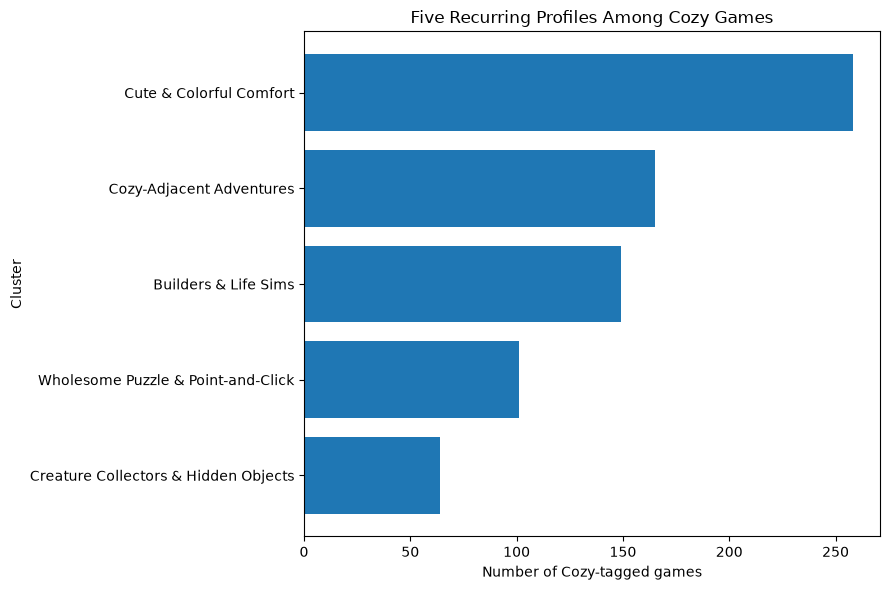

In [40]:
cluster_counts = (
    cozy_tagged_games["Cluster Name"]
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.barh(
    cluster_counts.index,
    cluster_counts.values
)

plt.xlabel("Number of Cozy-tagged games")
plt.ylabel("Cluster")
plt.title("Five Recurring Profiles Among Cozy Games")

plt.tight_layout()
plt.show()

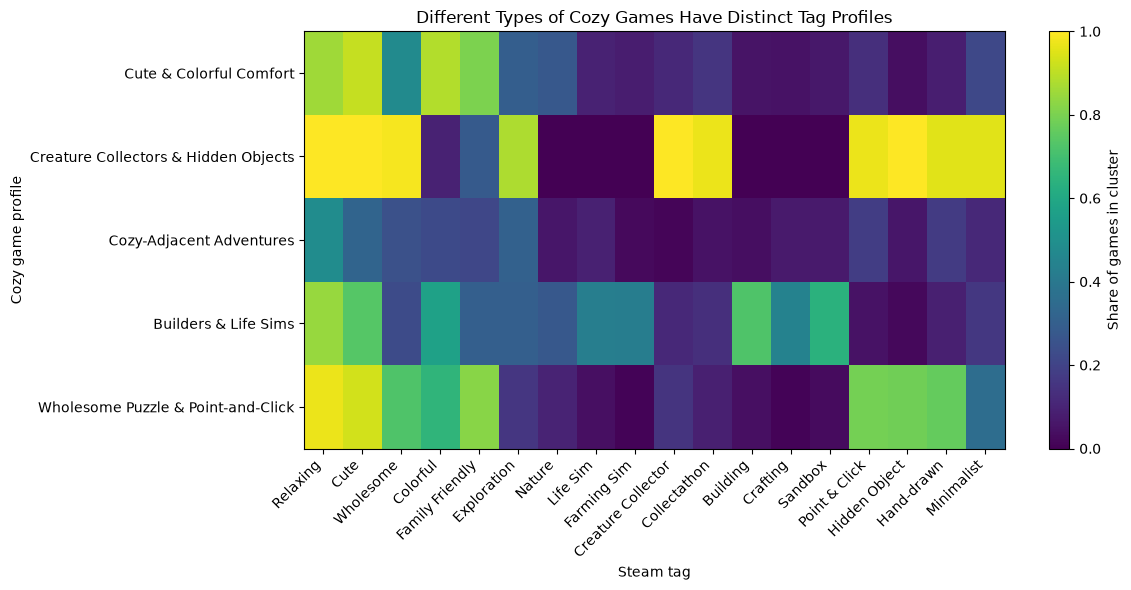

In [41]:
cluster_profiles_named = cluster_profiles.copy()

cluster_profiles_named.index = [
    cluster_names[i] for i in cluster_profiles_named.index
]

# Pick the most useful tags for explaining the clusters
profile_tags = [
    "Relaxing",
    "Cute",
    "Wholesome",
    "Colorful",
    "Family Friendly",
    "Exploration",
    "Nature",
    "Life Sim",
    "Farming Sim",
    "Creature Collector",
    "Collectathon",
    "Building",
    "Crafting",
    "Sandbox",
    "Point & Click",
    "Hidden Object",
    "Hand-drawn",
    "Minimalist"
]

profile_data = cluster_profiles_named[profile_tags]

plt.figure(figsize=(12, 6))

plt.imshow(
    profile_data,
    aspect="auto",
    vmin=0,
    vmax=1
)

plt.colorbar(label="Share of games in cluster")

plt.xticks(
    range(len(profile_tags)),
    profile_tags,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(profile_data.index)),
    profile_data.index
)

plt.title("Different Types of Cozy Games Have Distinct Tag Profiles")
plt.xlabel("Steam tag")
plt.ylabel("Cozy game profile")

plt.tight_layout()
plt.show()

### Cozy Game Profiles

Clustering reveals that Cozy-tagged games are not a single uniform category. Instead, the dataset contains several recurring profiles that combine similar emotional and visual qualities with different gameplay structures.

- **Cute & Colorful Comfort** emphasizes relaxing, cute, colorful, and family-friendly characteristics.
- **Creature Collectors & Hidden Objects** represents a smaller, highly specialized group centered around collecting, hidden-object, and point-and-click gameplay.
- **Cozy-Adjacent Adventures** contains games with weaker concentrations of the characteristics most strongly associated with Cozy games.
- **Builders & Life Sims** combines relaxing and cute qualities with building, crafting, sandbox, life-sim, and farming mechanics.
- **Wholesome Puzzle & Point-and-Click** emphasizes wholesome presentation alongside point-and-click, hidden-object, and hand-drawn characteristics.

Together, these clusters suggest that **coziness functions less like a traditional genre and more like a design profile that can emerge across different gameplay structures.**

In [42]:
cluster_summary = (
    cozy_tagged_games
    .groupby("Cluster Name")
    .size()
    .reset_index(name="Games")
)

cluster_summary["Percent of Cozy Games"] = (
    cluster_summary["Games"]
    / len(cozy_tagged_games)
    * 100
).round(1)

cluster_summary = (
    cluster_summary
    .sort_values("Games", ascending=False)
    .reset_index(drop=True)
)

cluster_summary

,Cluster Name,Games,Percent of Cozy Games
0,Cute & Colorful Comfort,258,35.0
1,Cozy-Adjacent Adventures,165,22.4
2,Builders & Life Sims,149,20.2
3,Wholesome Puzzle & Point-and-Click,101,13.7
4,Creature Collectors & Hidden Objects,64,8.7


## Conclusion

This analysis explored what distinguishes Cozy-tagged games on Steam and whether games within the category share a single common profile.

The results suggest that **cozy games are defined less by a traditional genre and more by a combination of emotional tone, visual style, and gameplay design**. Relaxing and Cute were among the most common characteristics, appearing in approximately 80% and 75% of Cozy-tagged games. Wholesome was especially distinctive: although present in about 45% of Cozy games, it appeared in less than 1% of the broader Steam dataset.

Gameplay characteristics also mattered. Tags such as Creature Collector, Farming Sim, Life Sim, Collection, and Nature were substantially more prevalent among Cozy-tagged games than among Steam games overall.

However, clustering showed that there is no single formula for a cozy game. Five recurring profiles emerged:

- **Cute & Colorful Comfort** — 35.0%
- **Cozy-Adjacent Adventures** — 22.4%
- **Builders & Life Sims** — 20.2%
- **Wholesome Puzzle & Point-and-Click** — 13.7%
- **Creature Collectors & Hidden Objects** — 8.7%

These profiles share some characteristics—particularly relaxation and cuteness—but differ substantially in their gameplay structures.

Overall, the findings suggest that **“cozy” functions as an umbrella design identity rather than a conventional genre**. A game can create a cozy experience through different combinations of low-pressure gameplay, comforting aesthetics, exploration, collecting, simulation, puzzles, and other mechanics.

## Limitations

This analysis relies on Steam tags, which reflect how games are categorized by users and developers rather than an objective definition of game design. Tag popularity may also vary based on a game's audience size, visibility, and release history.

The clustering analysis uses selected binary tags, meaning that games are grouped according to whether those tags are present rather than the intensity or importance of each characteristic. Cluster names were assigned after examining the most common tags and example games within each group and should therefore be interpreted as descriptive labels rather than official categories.

Finally, this analysis focuses on games explicitly tagged **Cozy** on Steam. Games commonly considered cozy by players but lacking that tag may not be represented.